In [1]:
# 1. Ensure all visualization libraries are present in the lab environment
!pip install --quiet seaborn matplotlib

# 2. Load core analytical packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean design aesthetic for the insurer client reports
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 3. Read the cleaned aviation dataset from your workspace
df = pd.read_csv('data/Cleaned_Aviation_Data.csv')

# 4. Segment the records using the client's 20-passenger fleet capacity threshold
small_planes = df[df['Total.Passengers'] <= 20].copy()
large_planes = df[df['Total.Passengers'] > 20].copy()

# Confirm structural matrices match expectations
print("Environment initialized and data parsed successfully!")
print(f"Total workspace records: {df.shape[0]}")
print(f" -> Small Aircraft Segment (<= 20 passengers): {small_planes.shape[0]} incidents")
print(f" -> Large Passenger Segment (> 20 passengers): {large_planes.shape[0]} incidents")


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Environment initialized and data parsed successfully!
Total workspace records: 17879
 -> Small Aircraft Segment (<= 20 passengers): 17006 incidents
 -> Large Passenger Segment (> 20 passengers): 873 incidents


C:\Users\USER\AppData\Local\Temp\ipykernel_22448\1893139336.py:15: DtypeWarning: Columns (0: Event.Id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/Cleaned_Aviation_Data.csv')


C:\Users\USER\AppData\Local\Temp\ipykernel_22448\3146851093.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\USER\AppData\Local\Temp\ipykernel_22448\3146851093.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


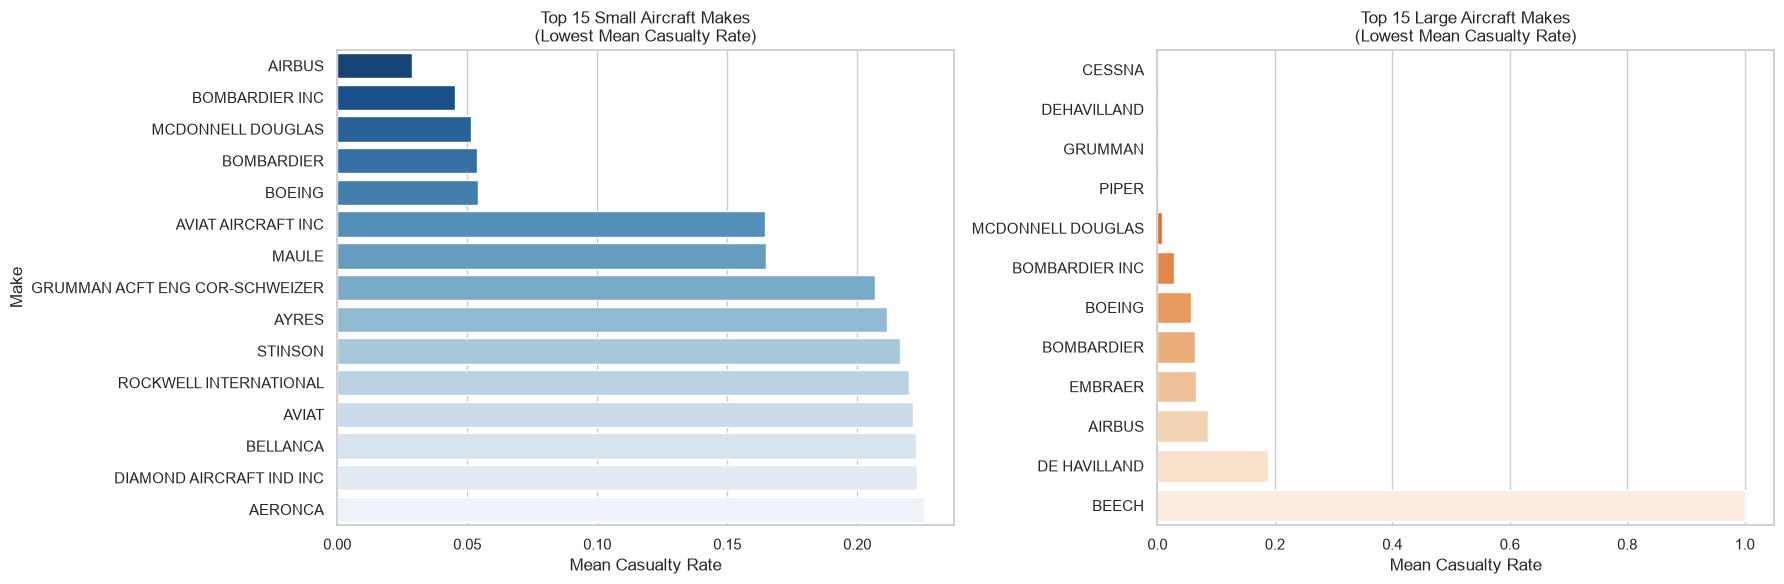

C:\Users\USER\AppData\Local\Temp\ipykernel_22448\3146851093.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\USER\AppData\Local\Temp\ipykernel_22448\3146851093.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


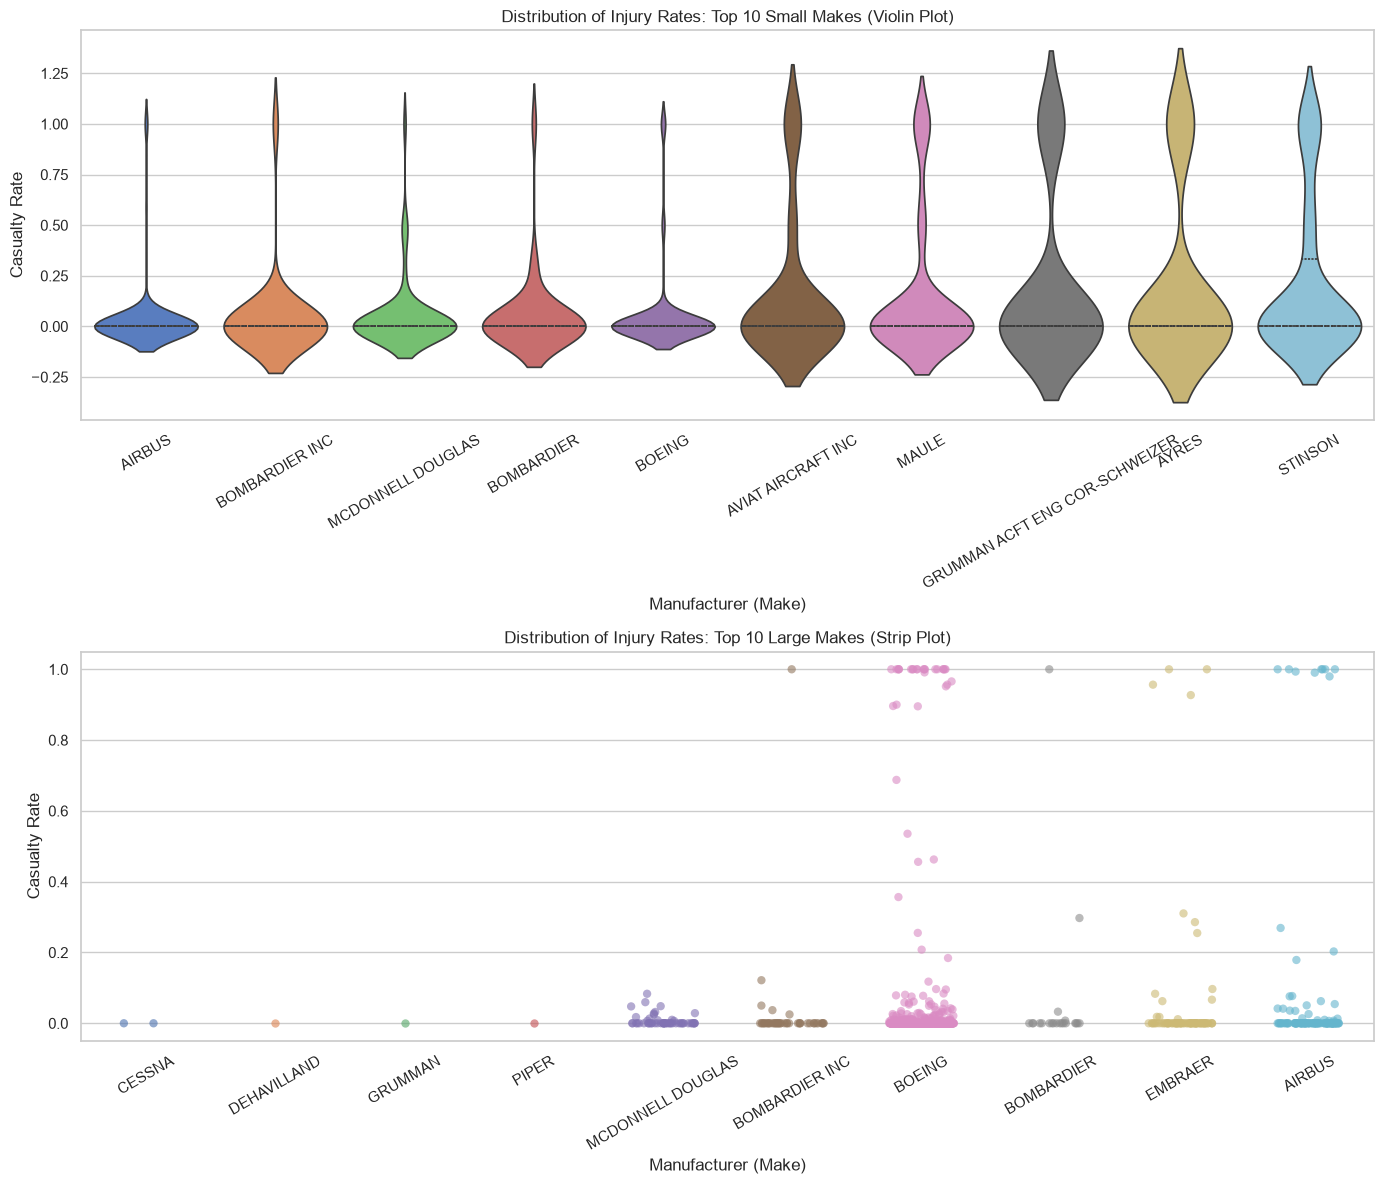

   SMALL AIRCRAFT MAKES: LOWEST RATIO OF TOTAL HULL LOSS 
                          Make  Is_Destroyed
                      LUSCOMBE      0.014184
GRUMMAN ACFT ENG COR-SCHWEIZER      0.017241
                       STINSON      0.023256
                        AIRBUS      0.024000
                   TAYLORCRAFT      0.032258
                    BOMBARDIER      0.034483
                       AERONCA      0.035000
                        BOEING      0.036415
    AMERICAN CHAMPION AIRCRAFT      0.038462
                       ERCOUPE      0.038462
            AVIAT AIRCRAFT INC      0.039474
                         MAULE      0.041860
                   DEHAVILLAND      0.042553
                BOMBARDIER INC      0.045455
                      BELLANCA      0.050228

   LARGE AIRCRAFT MAKES: LOWEST RATIO OF TOTAL HULL LOSS 
             Make  Is_Destroyed
           CESSNA      0.000000
      DEHAVILLAND      0.000000
          GRUMMAN      0.000000
            PIPER      0.000000
   

In [2]:
# ==========================================
# 1. SIDE-BY-SIDE BAR PLOTS (TOP 15 MAKES)
# ==========================================
# Group by Make and find the 15 makes with the lowest mean casualty rate
top_15_small_makes = small_planes.groupby('Make')['Casualty.Rate'].mean().nsmallest(15).index
top_15_large_makes = large_planes.groupby('Make')['Casualty.Rate'].mean().nsmallest(15).index

df_plot_small = small_planes[small_planes['Make'].isin(top_15_small_makes)]
df_plot_large = large_planes[large_planes['Make'].isin(top_15_large_makes)]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=df_plot_small, x='Casualty.Rate', y='Make', 
    order=top_15_small_makes, ax=axes[0], errorbar=None, palette='Blues_r'
)
axes[0].set_title('Top 15 Small Aircraft Makes\n(Lowest Mean Casualty Rate)', fontsize=12)
axes[0].set_xlabel('Mean Casualty Rate')

sns.barplot(
    data=df_plot_large, x='Casualty.Rate', y='Make', 
    order=top_15_large_makes, ax=axes[1], errorbar=None, palette='Oranges_r'
)
axes[1].set_title('Top 15 Large Aircraft Makes\n(Lowest Mean Casualty Rate)', fontsize=12)
axes[1].set_xlabel('Mean Casualty Rate')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# ==========================================
# 2. DISTRIBUTIONS (VIOLIN & STRIP PLOTS)
# ==========================================
# Filter down to the 10 lowest for detailed distribution plots as requested
top_10_small_makes = small_planes.groupby('Make')['Casualty.Rate'].mean().nsmallest(10).index
top_10_large_makes = large_planes.groupby('Make')['Casualty.Rate'].mean().nsmallest(10).index

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Violinplot for Small Makes
sns.violinplot(
    data=small_planes[small_planes['Make'].isin(top_10_small_makes)], 
    x='Make', y='Casualty.Rate', order=top_10_small_makes, palette='muted', inner='quartile', ax=axes[0]
)
axes[0].set_title('Distribution of Injury Rates: Top 10 Small Makes (Violin Plot)', fontsize=12)
axes[0].set_xlabel('Manufacturer (Make)')
axes[0].set_ylabel('Casualty Rate')
axes[0].tick_params(axis='x', rotation=30)

# Stripplot for Large Makes
sns.stripplot(
    data=large_planes[large_planes['Make'].isin(top_10_large_makes)], 
    x='Make', y='Casualty.Rate', order=top_10_large_makes, palette='deep', size=6, jitter=0.25, alpha=0.6, ax=axes[1]
)
axes[1].set_title('Distribution of Injury Rates: Top 10 Large Makes (Strip Plot)', fontsize=12)
axes[1].set_xlabel('Manufacturer (Make)')
axes[1].set_ylabel('Casualty Rate')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ==========================================
# 3. AIRCRAFT DESTRUCTION RATES
# ==========================================
small_dest_rate = small_planes.groupby('Make')['Is_Destroyed'].mean().nsmallest(15).reset_index()
large_dest_rate = large_planes.groupby('Make')['Is_Destroyed'].mean().nsmallest(15).reset_index()

print("=========================================================")
print("   SMALL AIRCRAFT MAKES: LOWEST RATIO OF TOTAL HULL LOSS ")
print("=========================================================")
print(small_dest_rate.to_string(index=False))

print("\n=========================================================")
print("   LARGE AIRCRAFT MAKES: LOWEST RATIO OF TOTAL HULL LOSS ")
print("=========================================================")
print(large_dest_rate.to_string(index=False))

C:\Users\USER\AppData\Local\Temp\ipykernel_22448\3588601999.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\USER\AppData\Local\Temp\ipykernel_22448\3588601999.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


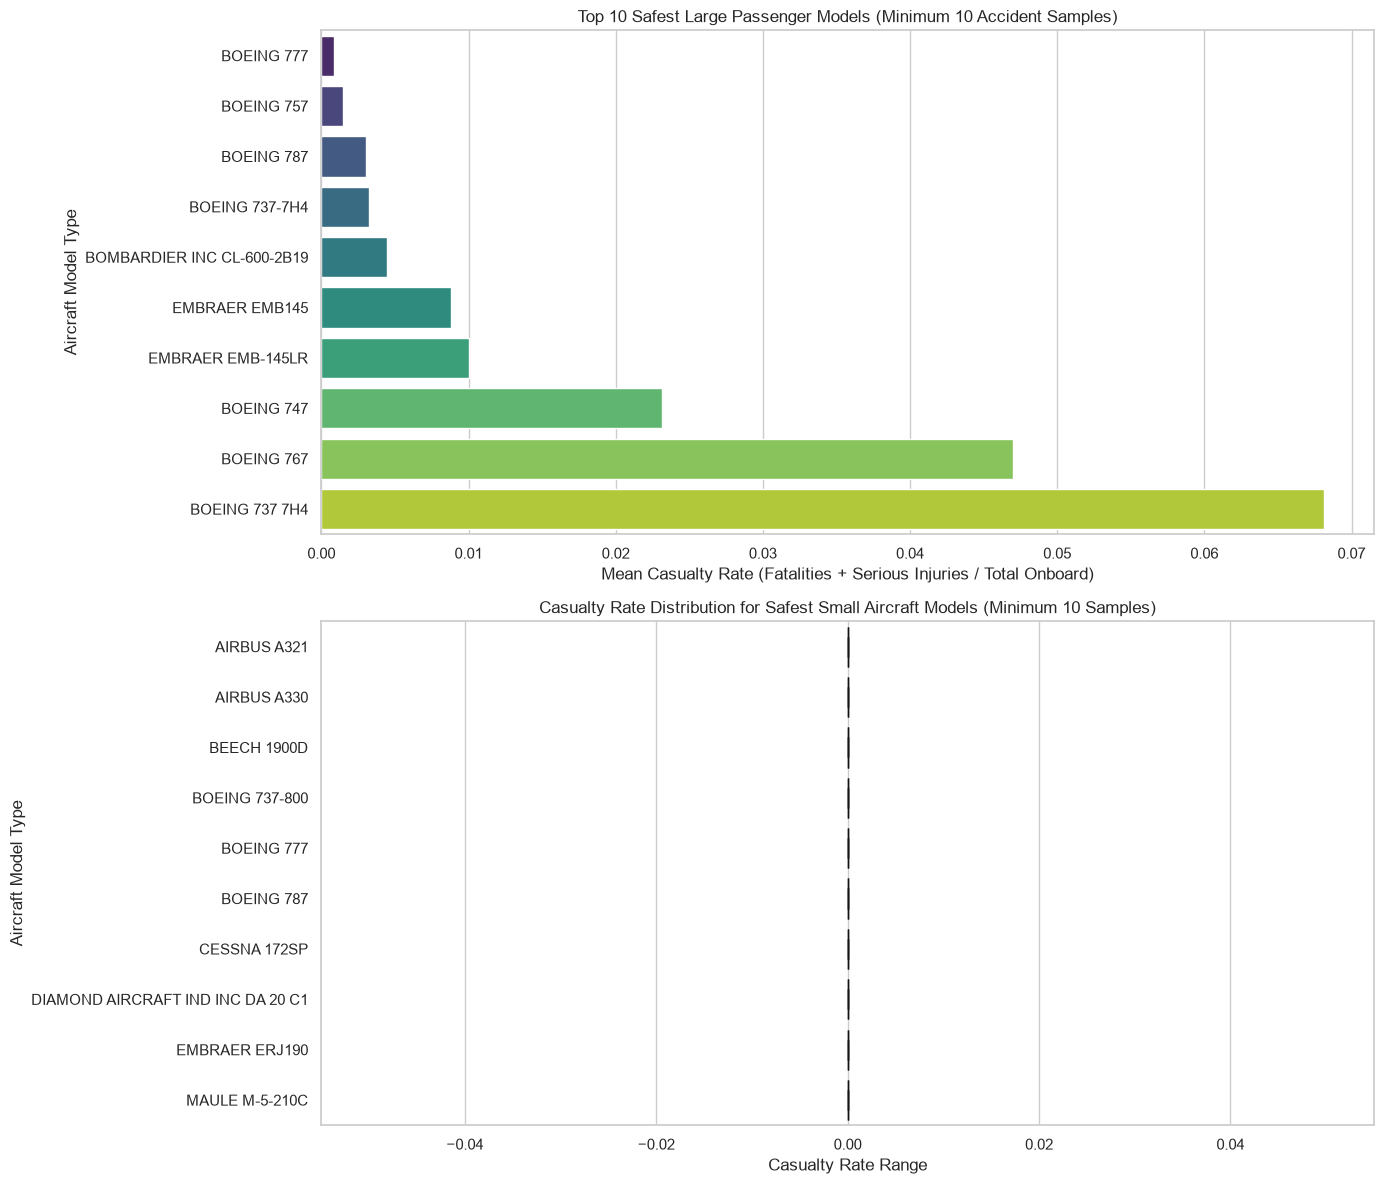

In [3]:
# ==========================================
# 1. ROBUST PASSENGER MODEL FILTER (N >= 10)
# ==========================================
# Group and identify unique model IDs with 10 or more documented accidents
small_model_counts = small_planes['Unique_Aircraft_ID'].value_counts()
robust_small_models = small_model_counts[small_model_counts >= 10].index
df_models_small_robust = small_planes[small_planes['Unique_Aircraft_ID'].isin(robust_small_models)]

large_model_counts = large_planes['Unique_Aircraft_ID'].value_counts()
robust_large_models = large_model_counts[large_model_counts >= 10].index
df_models_large_robust = large_planes[large_planes['Unique_Aircraft_ID'].isin(robust_large_models)]

# Identify the 10 safest models based on mean casualty rate
safest_models_large = df_models_large_robust.groupby('Unique_Aircraft_ID')['Casualty.Rate'].mean().nsmallest(10).index

# For small models, limit the selection to the 10 lowest mean casualty rates as requested
safest_models_small = df_models_small_robust.groupby('Unique_Aircraft_ID')['Casualty.Rate'].mean().nsmallest(10).index

# ==========================================
# 2. GENERATE PLOTS FOR MODEL RECS
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot A: Large Planes Bar Plot
sns.barplot(
    data=df_models_large_robust[df_models_large_robust['Unique_Aircraft_ID'].isin(safest_models_large)],
    x='Casualty.Rate', y='Unique_Aircraft_ID', order=safest_models_large, 
    palette='viridis', errorbar=None, ax=axes[0]
)
axes[0].set_title('Top 10 Safest Large Passenger Models (Minimum 10 Accident Samples)', fontsize=12)
axes[0].set_xlabel('Mean Casualty Rate (Fatalities + Serious Injuries / Total Onboard)')
axes[0].set_ylabel('Aircraft Model Type')

# Plot B: Small Planes Distributional Plot (Boxplot)
sns.boxplot(
    data=df_models_small_robust[df_models_small_robust['Unique_Aircraft_ID'].isin(safest_models_small)],
    x='Casualty.Rate', y='Unique_Aircraft_ID', order=safest_models_small, 
    palette='magma', ax=axes[1]
)
axes[1].set_title('Casualty Rate Distribution for Safest Small Aircraft Models (Minimum 10 Samples)', fontsize=12)
axes[1].set_xlabel('Casualty Rate Range')
axes[1].set_ylabel('Aircraft Model Type')

plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_22448\1988785771.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\USER\AppData\Local\Temp\ipykernel_22448\1988785771.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


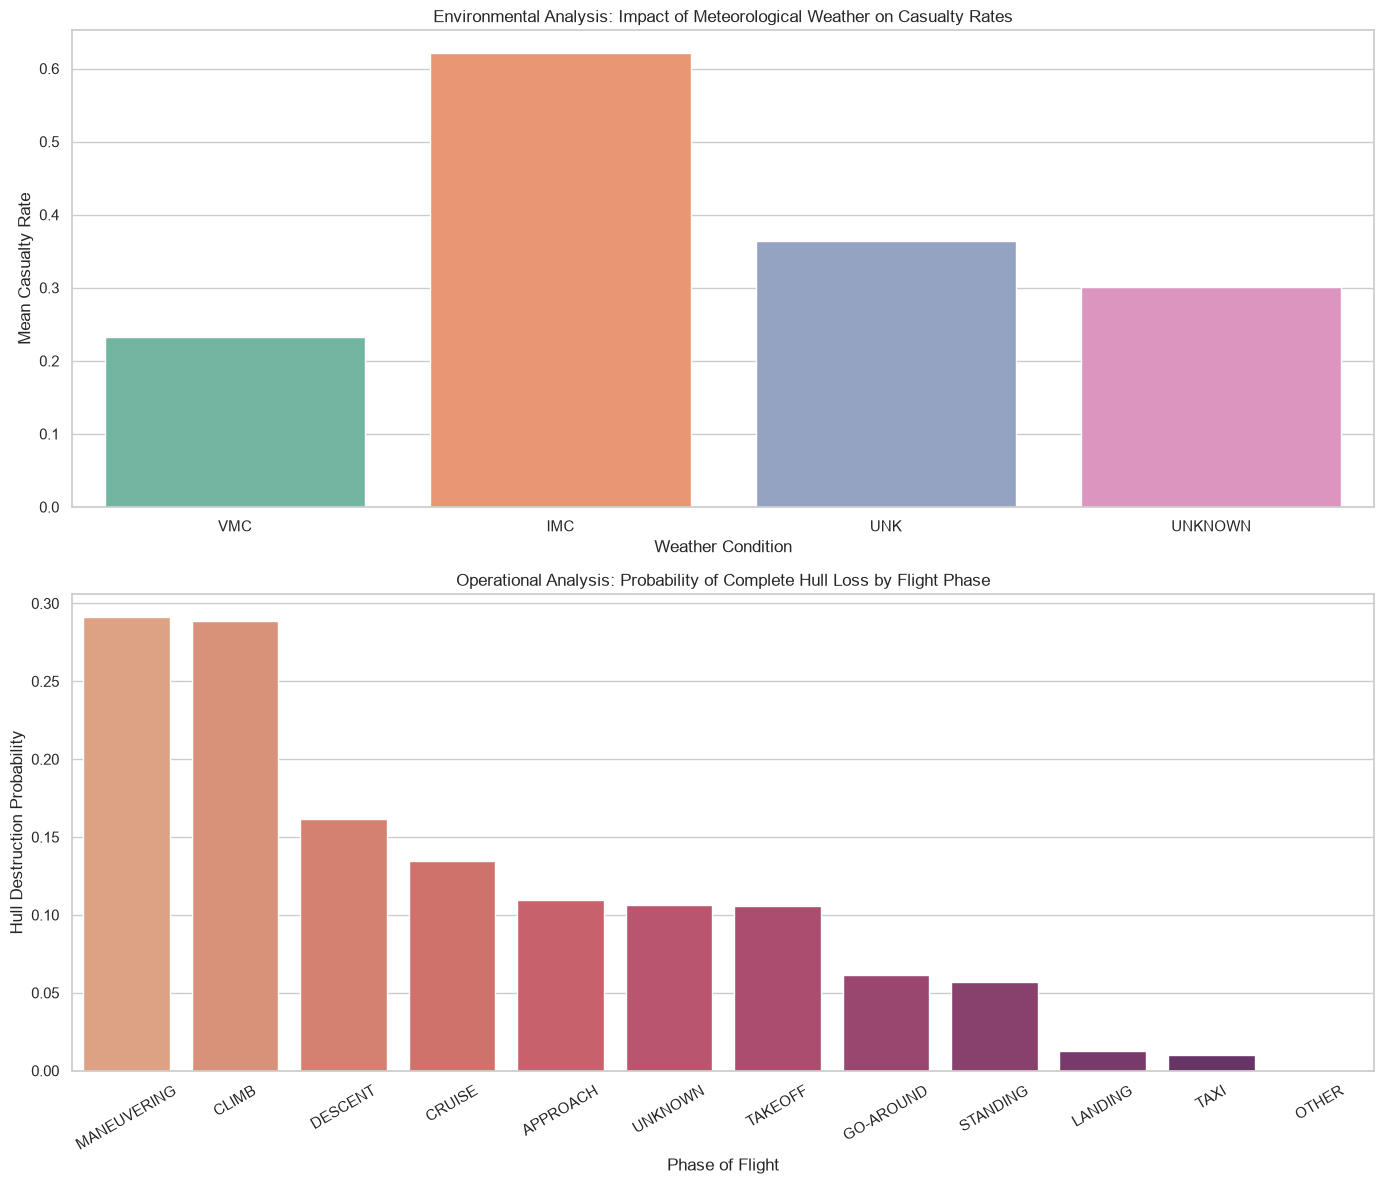

Notebook execution completely restored and final analysis completed successfully!


In [4]:
# ==========================================
# EXPLORING OPERATIONAL & RISK VARIABLES
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# 1. Factor 1: Weather Condition vs. Casualty Rates
sns.barplot(
    data=df, x='Weather.Condition', y='Casualty.Rate', 
    palette='Set2', errorbar=None, ax=axes[0]
)
axes[0].set_title('Environmental Analysis: Impact of Meteorological Weather on Casualty Rates', fontsize=12)
axes[0].set_ylabel('Mean Casualty Rate')
axes[0].set_xlabel('Weather Condition')

# 2. Factor 2: Flight Phase vs. Hull Destruction Probability
# Sort the flight phases by destruction rate to make the chart easy to read
phase_order = df.groupby('Broad.phase.of.flight')['Is_Destroyed'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df, x='Broad.phase.of.flight', y='Is_Destroyed', 
    order=phase_order, palette='flare', errorbar=None, ax=axes[1]
)
axes[1].set_title('Operational Analysis: Probability of Complete Hull Loss by Flight Phase', fontsize=12)
axes[1].set_ylabel('Hull Destruction Probability')
axes[1].set_xlabel('Phase of Flight')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("Notebook execution completely restored and final analysis completed successfully!")